In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "dataset/spam.csv",
    encoding="latin-1"
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 Rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [4]:
print("Dataset Columns:")
for column in df.columns:
    print(repr(column))

Dataset Columns:
'v1'
'v2'
'Unnamed: 2'
'Unnamed: 3'
'Unnamed: 4'


In [5]:
# Check the first few rows
display(df.head())

# Remove unnecessary columns if they exist
columns_to_drop = [col for col in df.columns if "Unnamed" in col]

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

print("Columns after cleaning:")
print(df.columns.tolist())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Columns after cleaning:
['v1', 'v2']


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['v1', 'v2']

Dataset shape:
(5572, 2)

Missing values:
v1    0
v2    0
dtype: int64


In [7]:
print("\nValue counts:")
print(df.iloc[:, 0].value_counts())


Value counts:
v1
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
# Keep only the useful columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["label", "message"]

# Remove missing values
df = df.dropna()

print("Dataset after cleaning:")
print("Shape:", df.shape)

display(df.head())

Dataset after cleaning:
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Number of messages in each class:")
print(df["label"].value_counts())

Number of messages in each class:
label
ham     4825
spam     747
Name: count, dtype: int64


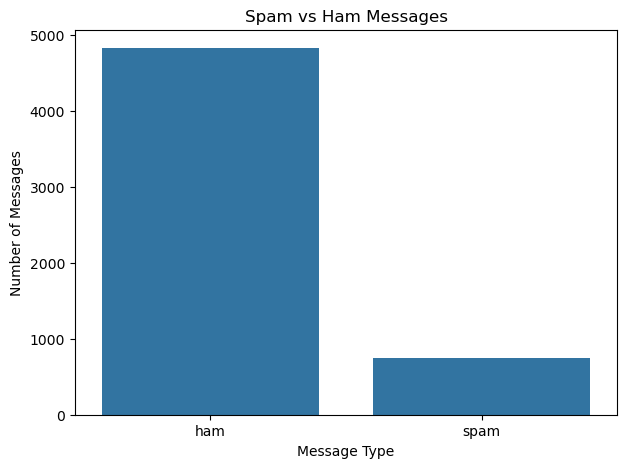

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [11]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Label conversion:")
display(df[["label", "label_num", "message"]].head(10))

Label conversion:


,label,label_num,message
0,ham,0,"Go until jurong point, crazy.. Available only ..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives aro..."
5,spam,1,FreeMsg Hey there darling it's been 3 week's n...
6,ham,0,Even my brother is not like to speak with me. ...
7,ham,0,As per your request 'Melle Melle (Oru Minnamin...
8,spam,1,WINNER!! As a valued network customer you have...
9,spam,1,Had your mobile 11 months or more? U R entitle...


In [12]:
df["message_length"] = df["message"].apply(len)

print("Message length statistics:")
display(df["message_length"].describe())

Message length statistics:


count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: message_length, dtype: float64

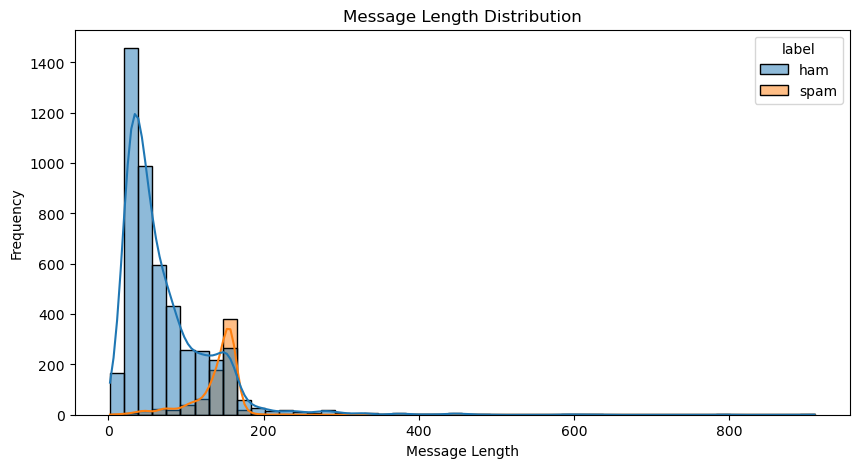

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

## Exploratory Data Analysis

The dataset contains two types of messages: ham and spam.

The class distribution shows the number of legitimate and spam messages.
Message length was also analyzed to understand whether spam messages tend
to have different lengths compared with legitimate messages.

The exploratory analysis provides an initial understanding of the dataset
before applying machine learning techniques.

In [14]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion completed!")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training feature shape: (4457, 5000)
Testing feature shape: (1115, 5000)


## Text Feature Extraction

Machine learning algorithms require numerical input, so the message text was
converted into numerical features using TF-IDF (Term Frequency-Inverse
Document Frequency).

TF-IDF gives higher importance to words that are useful for distinguishing
between spam and legitimate messages while reducing the importance of very
common words.

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f"{name} trained successfully!")

Naive Bayes trained successfully!
Logistic Regression trained successfully!


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

for name, model in models.items():
    predictions = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Ham", "Spam"]
    ))

Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Logistic Regression
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [20]:
results_df = pd.DataFrame(results)

results_df["Accuracy (%)"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df["Precision (%)"] = (
    results_df["Precision"] * 100
).round(2)

results_df["Recall (%)"] = (
    results_df["Recall"] * 100
).round(2)

results_df["F1 Score (%)"] = (
    results_df["F1 Score"] * 100
).round(2)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Naive Bayes,0.970404,0.991525,0.785235,0.876404,97.04,99.15,78.52,87.64
1,Logistic Regression,0.968610,0.991379,0.771812,0.867925,96.86,99.14,77.18,86.79


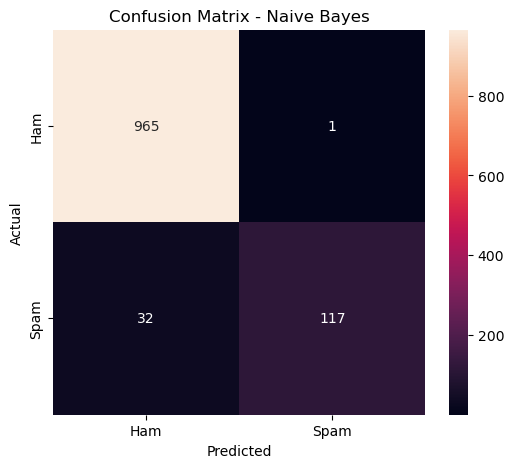

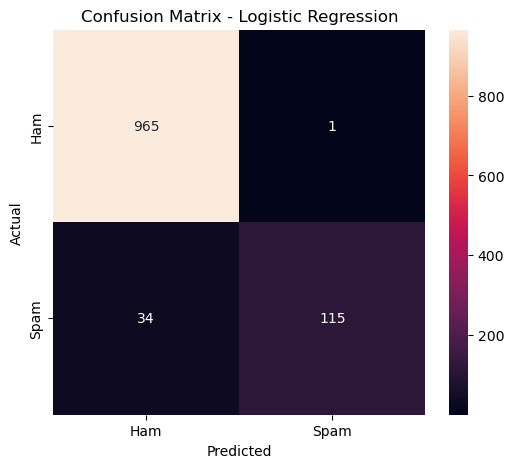

In [21]:
for name, model in models.items():

    predictions = model.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [22]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print(
    f"Best F1 Score: "
    f"{results_df.loc[results_df['F1 Score'].idxmax(), 'F1 Score']:.4f}"
)

Best Model: Naive Bayes
Best F1 Score: 0.8764


In [23]:
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = best_model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"


test_messages = [
    "Congratulations! You have won a free prize. Call now to claim it!",
    "Hey, are we meeting for lunch today?",
    "URGENT! You have won a cash reward. Click the link to claim now!",
    "Can you send me the assignment when you get time?"
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_spam(message))
    print("-" * 70)

Message: Congratulations! You have won a free prize. Call now to claim it!
Prediction: SPAM
----------------------------------------------------------------------
Message: Hey, are we meeting for lunch today?
Prediction: HAM
----------------------------------------------------------------------
Message: URGENT! You have won a cash reward. Click the link to claim now!
Prediction: SPAM
----------------------------------------------------------------------
Message: Can you send me the assignment when you get time?
Prediction: HAM
----------------------------------------------------------------------


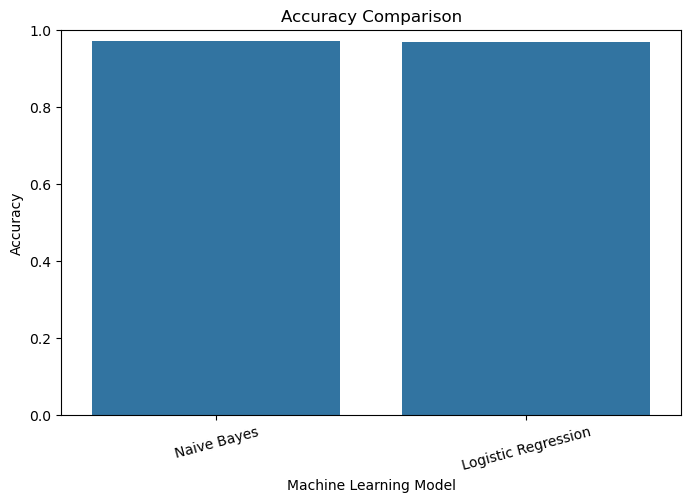

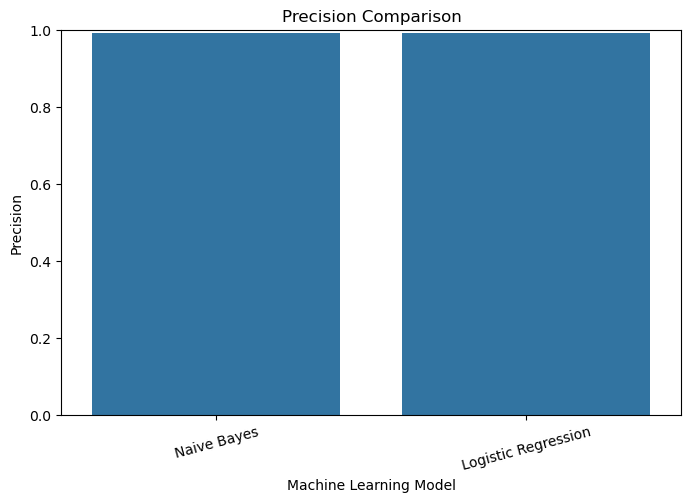

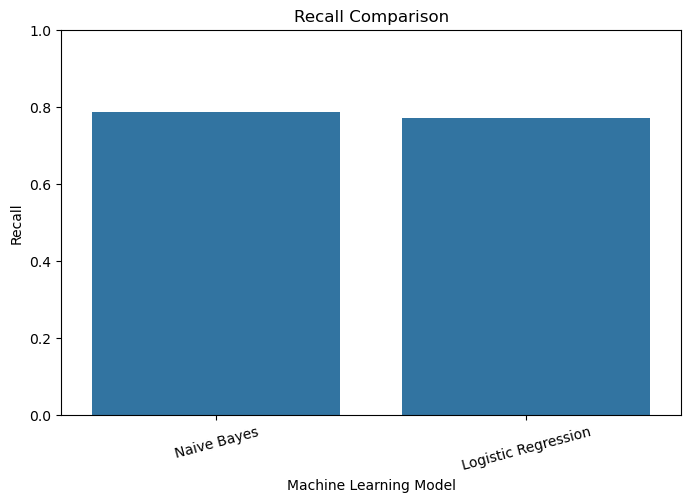

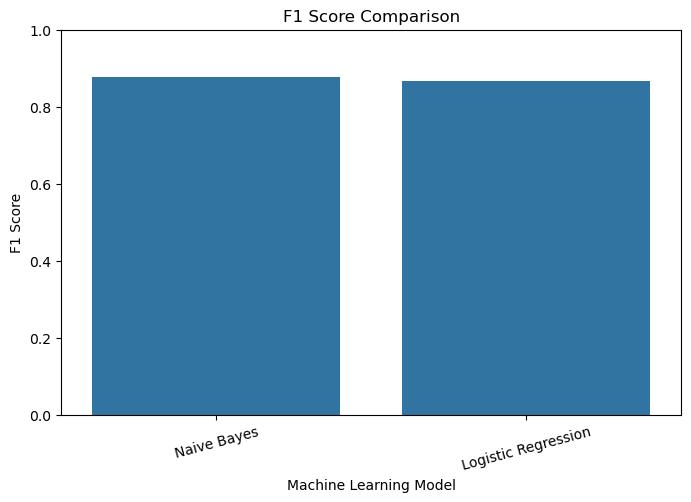

In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric
    )

    plt.title(f"{metric} Comparison")
    plt.xlabel("Machine Learning Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)

    plt.show()

## Conclusion

This project developed a machine learning model for detecting spam messages.

The dataset was cleaned and explored before applying natural language
processing techniques. TF-IDF was used to convert text messages into numerical
features suitable for machine learning.

Two classification algorithms were implemented:

1. Multinomial Naive Bayes
2. Logistic Regression

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The best-performing model was selected based on its F1-score and was then used
to classify new messages as either SPAM or HAM.

Overall, this project demonstrates how Natural Language Processing and
machine learning can be used to automatically detect unwanted spam messages.